<center><font size=8>Stock_Analysis</center></font>


<center><p float="center">
  <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQEtr22UkeoMZnFCftID0sh5ZO-uCM7wKXp5dLpcf2CRsa_x_gvQ80wQEA8&s=10" width="720"/>
</p></center>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/Dataset/GenAIDataset/stock_news (1).csv")

In [6]:
# creating a copy of the data
data = News.copy()

## **Data Overview**

###**Checking the first 5 rows**

In [7]:
data.head(5)

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [8]:
data.tail(5)

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [9]:
data.shape

(349, 8)

###**Checking for missing values**

In [63]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0
News_Length,0
YearMonth,0


### **Checking for duplicate values**

In [64]:

data.duplicated().sum()

0

## **Exploratory Data Analysis**

In [65]:
# To display the structure of the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         349 non-null    datetime64[ns]
 1   News         349 non-null    object        
 2   Open         349 non-null    float64       
 3   High         349 non-null    float64       
 4   Low          349 non-null    float64       
 5   Close        349 non-null    float64       
 6   Volume       349 non-null    int64         
 7   Label        349 non-null    int64         
 8   News_Length  349 non-null    int64         
 9   YearMonth    349 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 27.4+ KB


In [66]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

In [67]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         349 non-null    datetime64[ns]
 1   News         349 non-null    object        
 2   Open         349 non-null    float64       
 3   High         349 non-null    float64       
 4   Low          349 non-null    float64       
 5   Close        349 non-null    float64       
 6   Volume       349 non-null    int64         
 7   Label        349 non-null    int64         
 8   News_Length  349 non-null    int64         
 9   YearMonth    349 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 27.4+ KB


In [68]:
#summary stastical for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label,News_Length
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441,48.349570
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000,18.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000,45.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000,49.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000,52.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000,60.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119,5.717324


### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

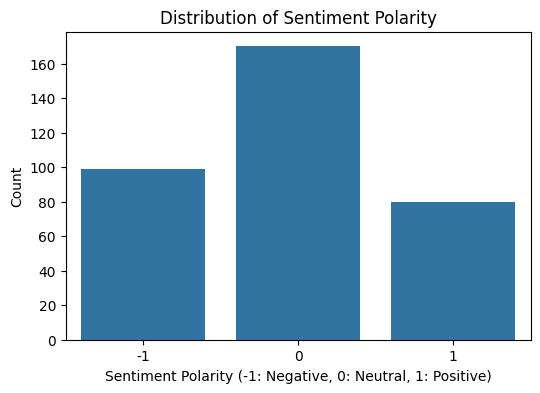

In [69]:
# Distribution of sentiment polarity
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('Count')
plt.show()

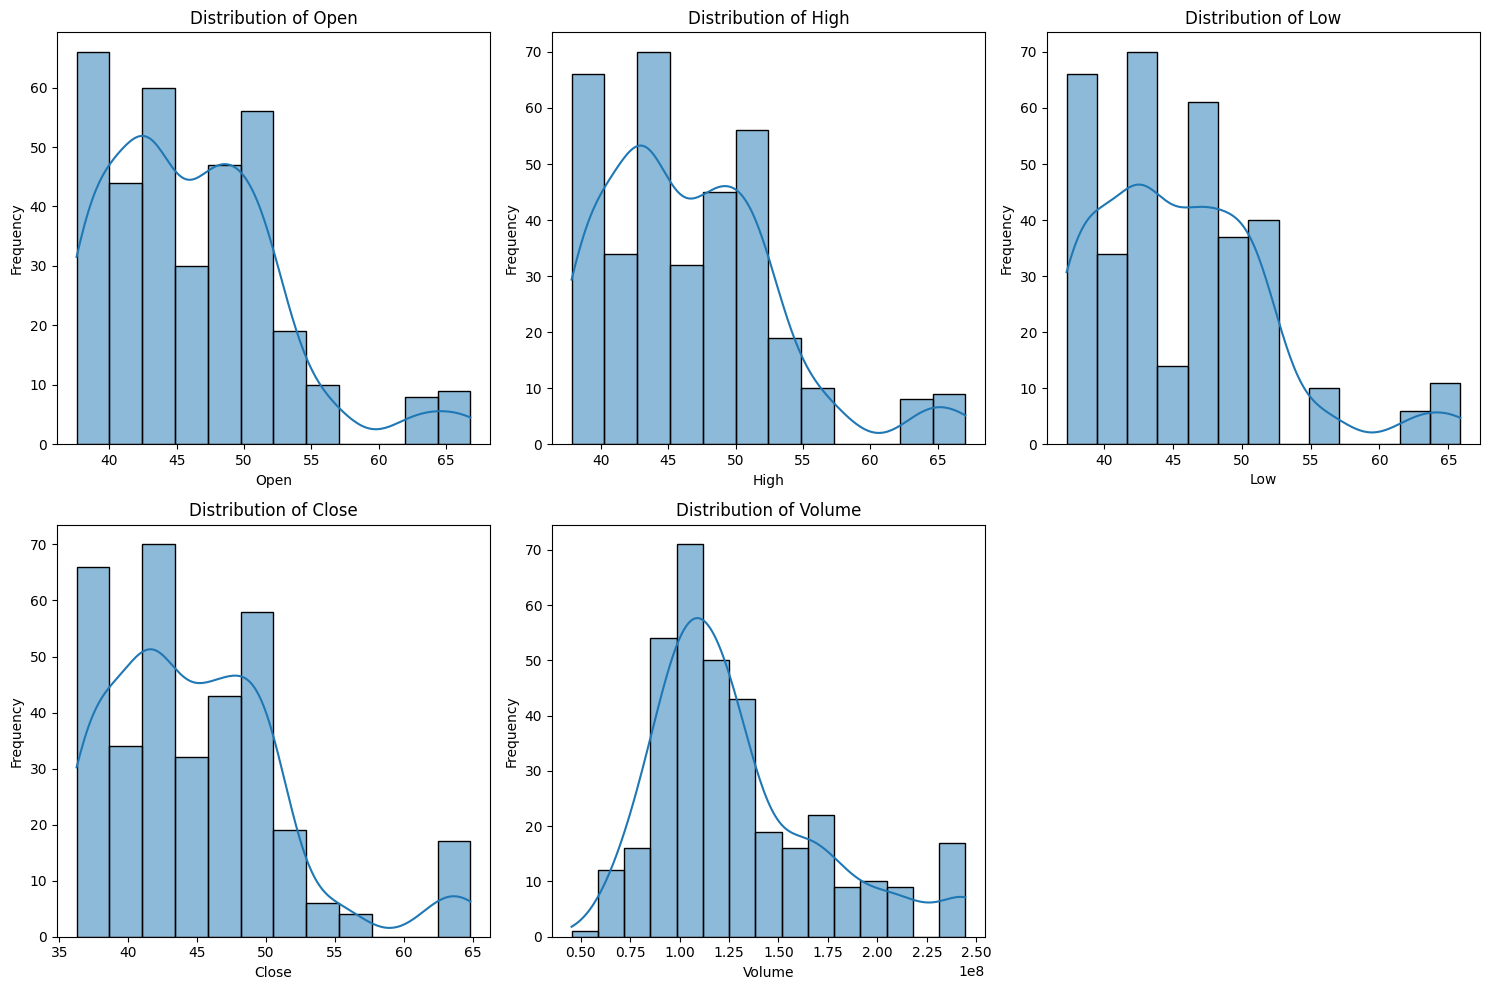

In [70]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### **Distribution of the length of news content**

In [71]:
# Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(str(x).split()))

# Summary statistics of news length
display(data['News_Length'].describe())

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


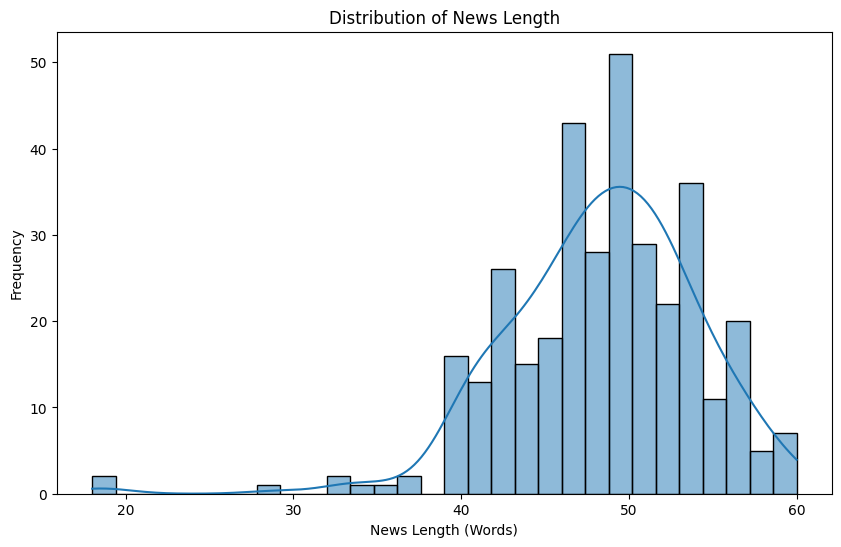

In [72]:
# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['News_Length'], kde=True, bins=30)
plt.title('Distribution of News Length')
plt.xlabel('News Length (Words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

In [73]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


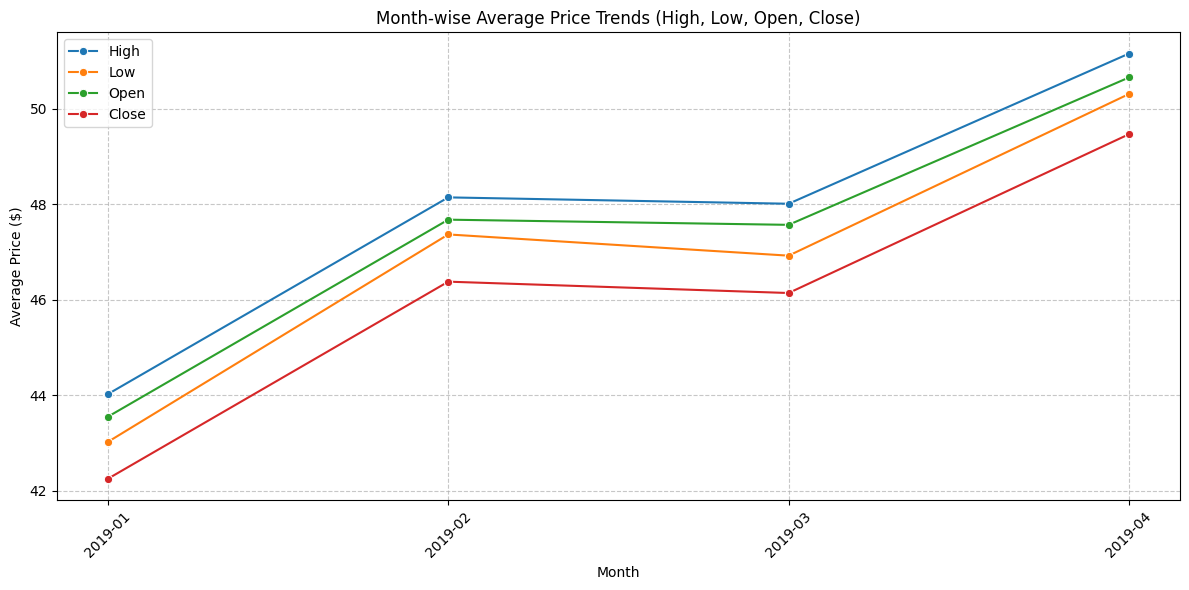

In [74]:
# plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12, 6))
price_cols = ['High', 'Low', 'Open', 'Close']
for col in price_cols:
    sns.lineplot(x='YearMonth', y=col, data=monthwise_avg, marker='o', label=col)
plt.title('Month-wise Average Price Trends (High, Low, Open, Close)')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

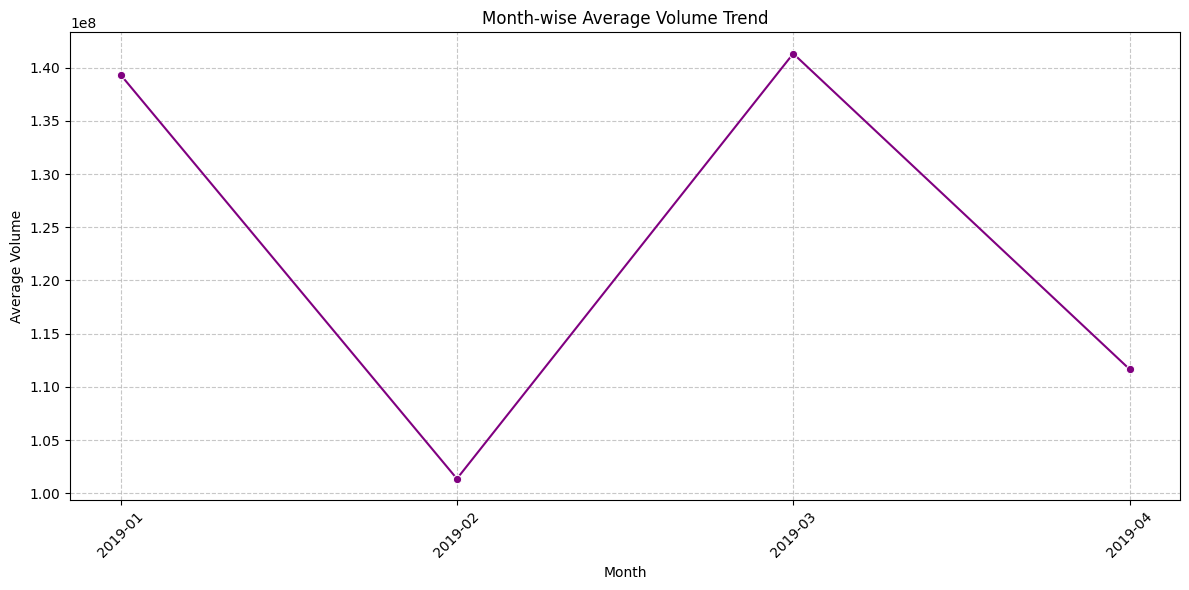

In [75]:
#plot the trend of monthwise average in Volume
plt.figure(figsize=(12, 6))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg, marker='o', color='purple')
plt.title('Month-wise Average Volume Trend')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

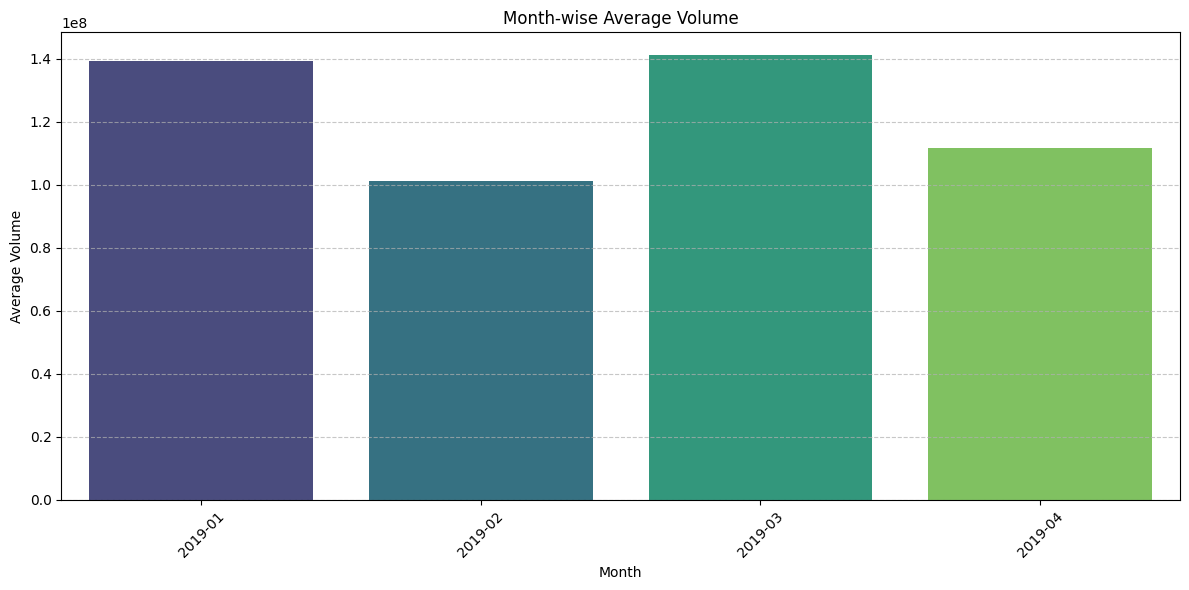

In [76]:
#Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, palette='viridis')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

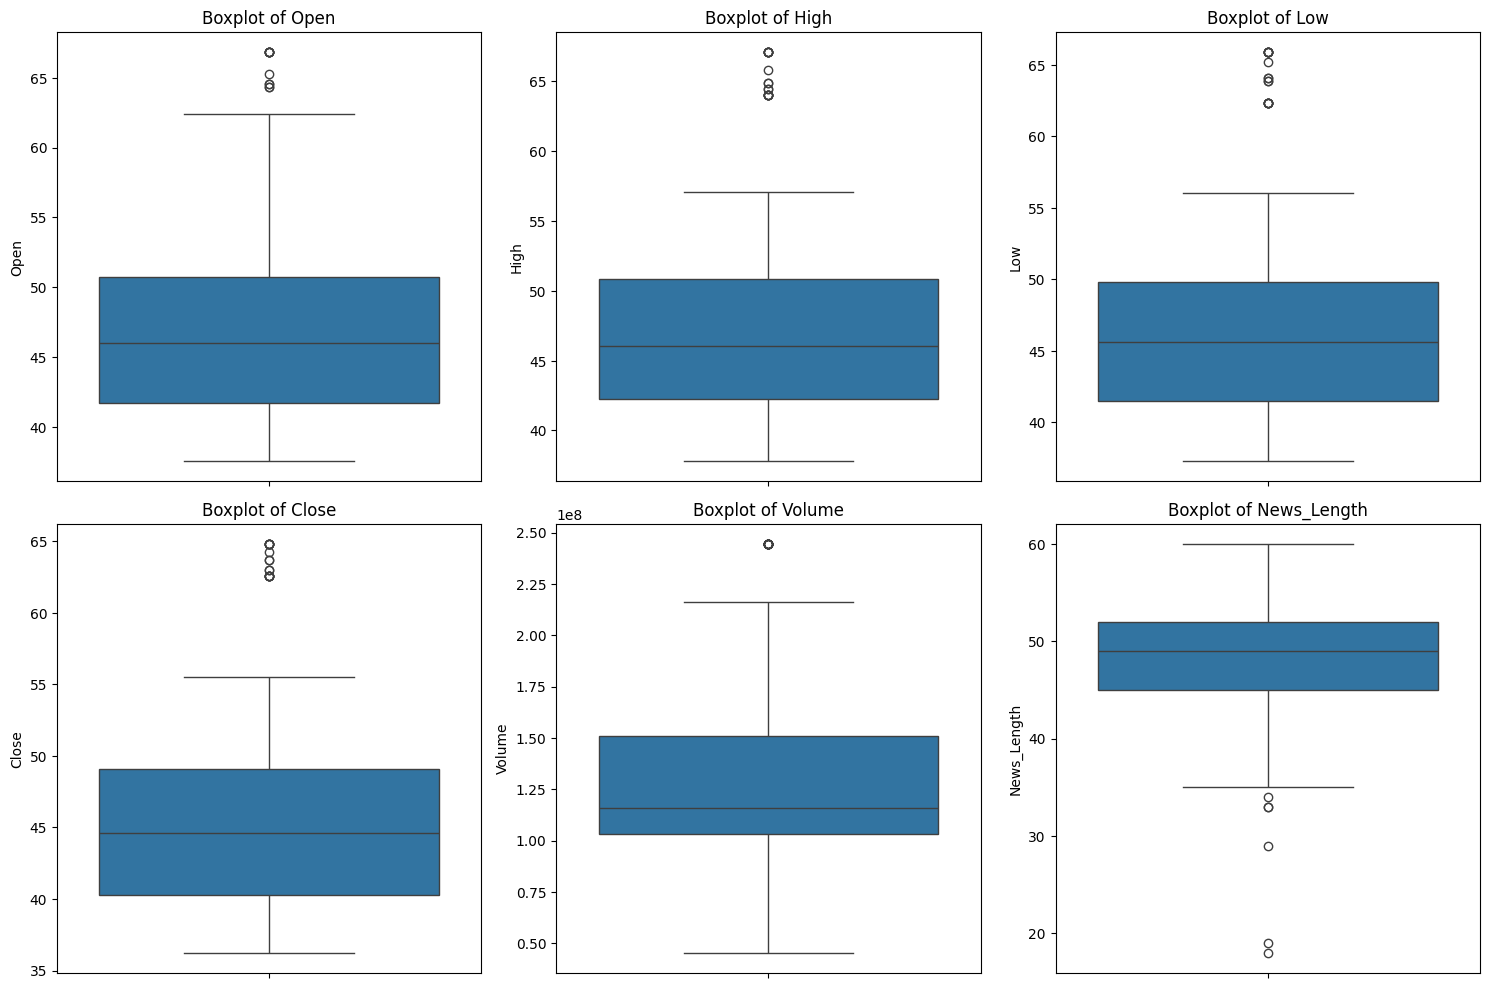

In [77]:
# Boxplot to identify outliers
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

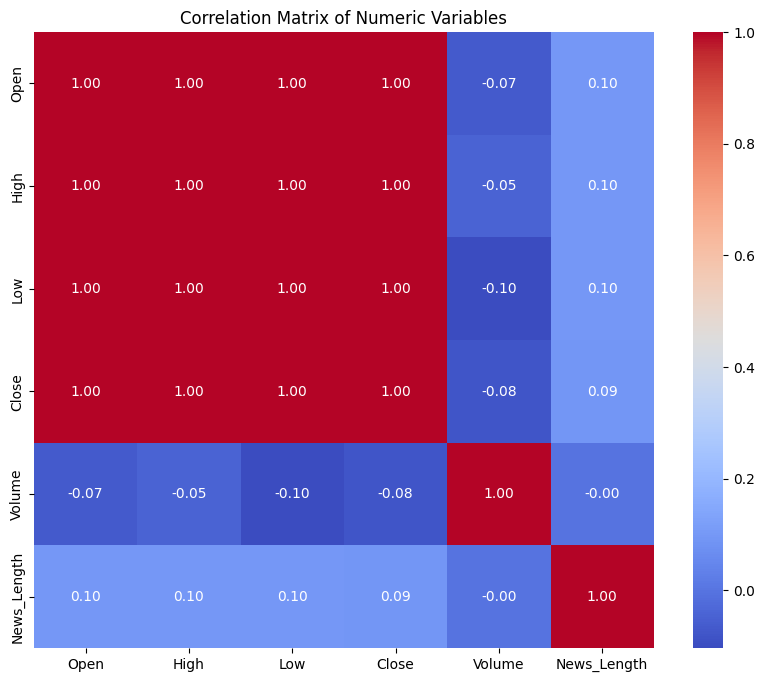

In [78]:
#Corelation matrix to check if variables move together or have correlations
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']
correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

### **Sentiment Polarity vs Price**

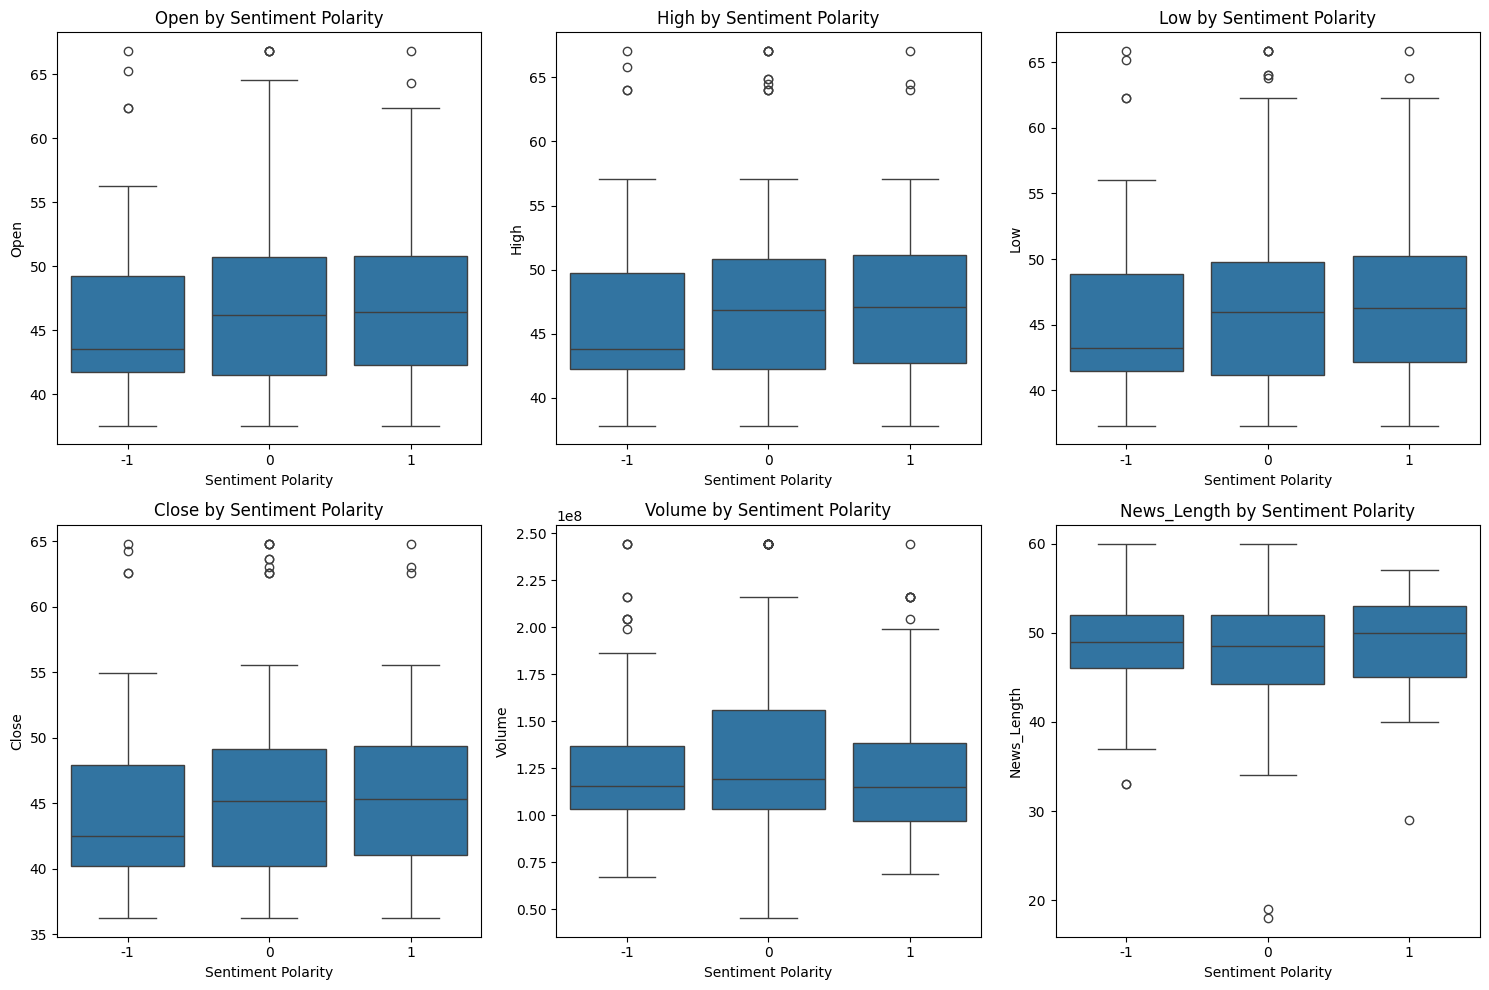

In [79]:
#sentiment Polarity with all numeric values

numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in 2 rows, 3 columns
    sns.boxplot(x='Label', y=col, data=data)
    plt.title(f'{col} by Sentiment Polarity')
    plt.xlabel('Sentiment Polarity')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

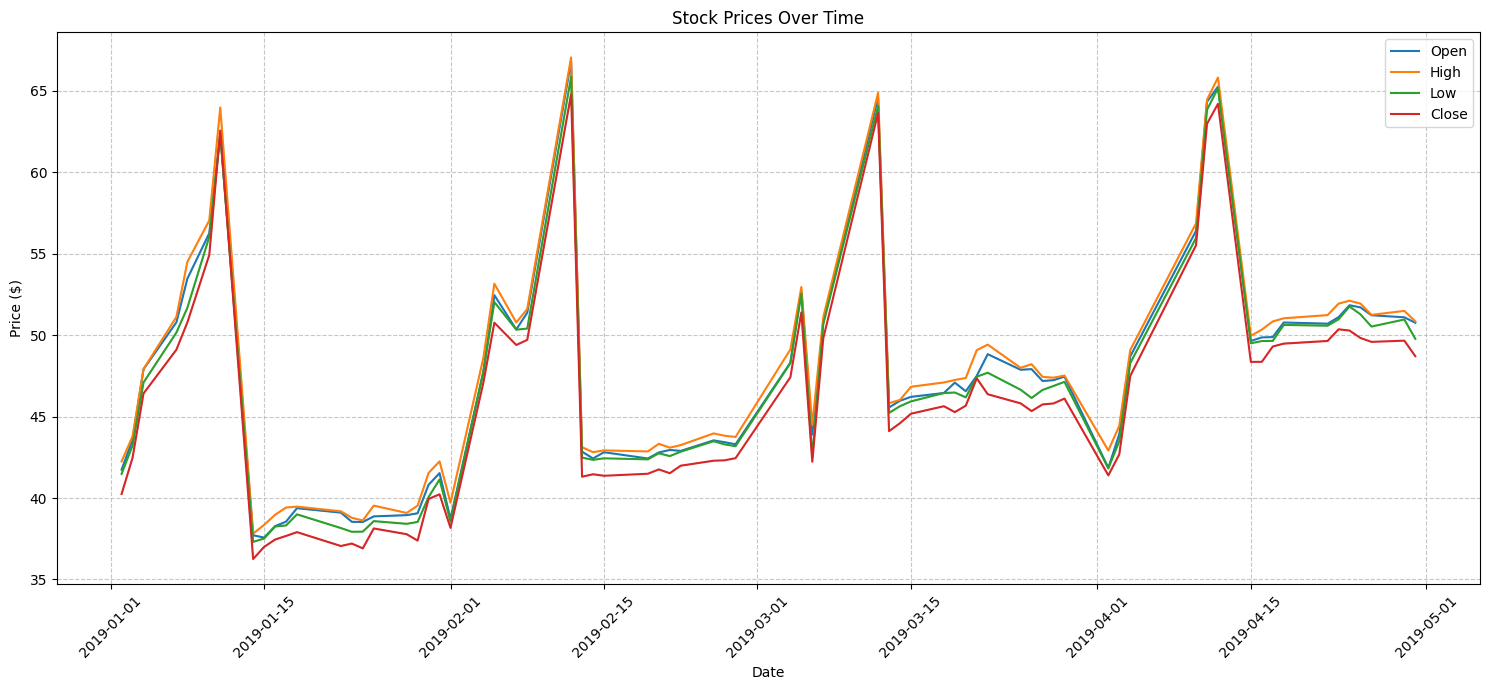

In [80]:
#Time Series Analysis (Date vs price columns)
plt.figure(figsize=(15, 7))
price_cols = ['Open', 'High', 'Low', 'Close']

for col in price_cols:
    sns.lineplot(x='Date', y=col, data=data, label=col)

plt.title('Stock Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Distribution of News Length Across Sentiment Categories**

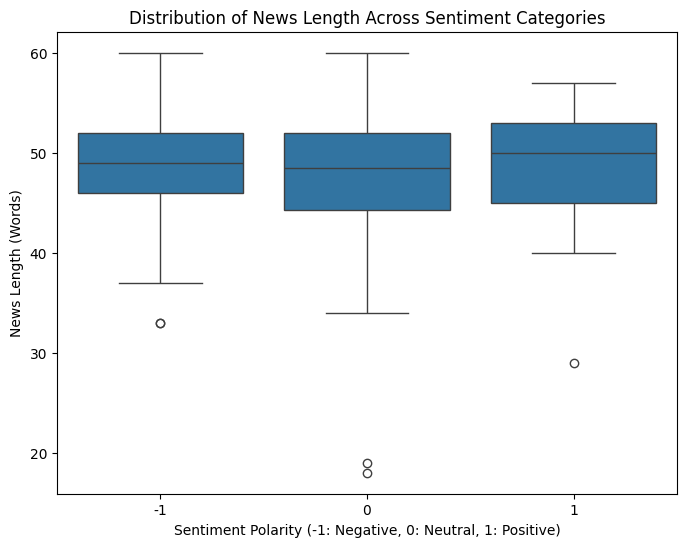

In [81]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='News_Length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Polarity (-1: Negative, 0: Neutral, 1: Positive)')
plt.ylabel('News Length (Words)')
plt.show()

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [82]:
# Storing target variable
y = data['Label']

## **Word Embeddings**


#### **Word2Vec**

In [83]:
# Creating a list of all words in our data
all_words = [word for news in data['News'] for word in str(news).split()]

In [84]:
vec_size = 300  # Set the desired vector size for Word2Vec
word2vec_model = Word2Vec(sentences=[all_words], vector_size=vec_size, window=5, min_count=1, workers=4)
words = word2vec_model.wv.index_to_key

In [85]:
word_vector_dict = {word: word2vec_model.wv[word] for word in words}
print(f"Number of words in vocabulary: {len(words)}")
print(f"Vector size: {vec_size}")

Number of words in vocabulary: 4681
Vector size: 300


In [86]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

In [87]:
# creating a dataframe of the vectorized documents
X = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in data['News']])

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [88]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

##### Encoding the dataset

In [89]:
embedding_matrix = model.encode(data['News'].tolist())

In [90]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [93]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

In [94]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [95]:
# Storing independent variable
X_word2vec = X

In [96]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [97]:
# Building the model
model_word2vec_rf = RandomForestClassifier(random_state=42)

# Fitting on train data
model_word2vec_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [98]:
y_pred_train = model_word2vec_rf.predict(X_train)
y_pred_test = model_word2vec_rf.predict(X_test)

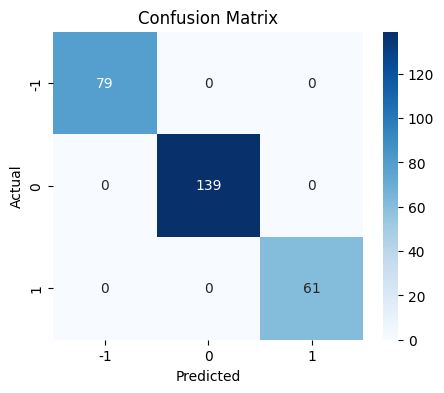

In [99]:
plot_confusion_matrix(y_train, y_pred_train)

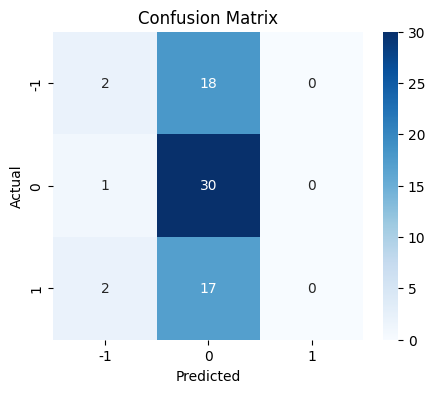

In [100]:
plot_confusion_matrix(y_test, y_pred_test)

In [101]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision     F1
 0.457143 0.457143   0.318681 0.3225


###**Sentence Transformer-Random Forest Model**

In [103]:
# Storing independent variable
X = embedding_matrix


In [104]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [105]:
# Building the model
model_transformer_rf = RandomForestClassifier(random_state=42)

# Fitting on train data
model_transformer_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [106]:
y_pred_train = model_transformer_rf.predict(X_train)
y_pred_test = model_transformer_rf.predict(X_test)

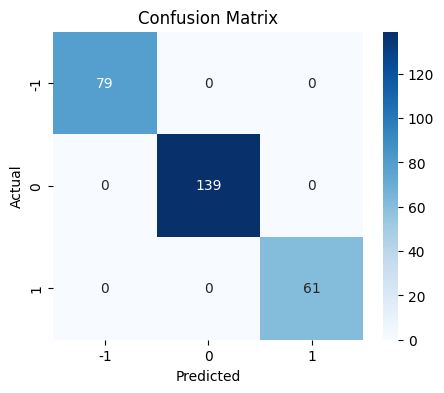

In [107]:
plot_confusion_matrix(y_train, y_pred_train)

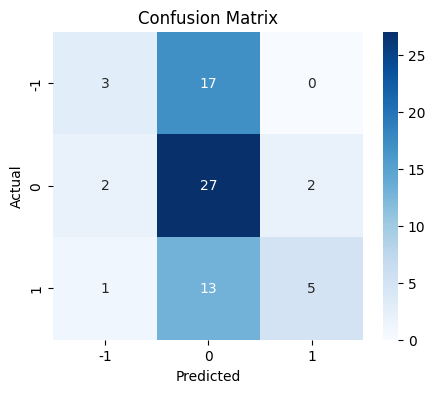

In [108]:
plot_confusion_matrix(y_test, y_pred_test)

In [109]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [110]:
# Storing independent variable
X = X_word2vec

In [111]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

In [112]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [113]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,979 (183.51 KB)

 Trainable params: 46,979 (183.51 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4875 - loss: 1.0853 - val_accuracy: 0.4429 - val_loss: 1.0840
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4982 - loss: 1.0638 - val_accuracy: 0.4429 - val_loss: 1.0755
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.4982 - loss: 1.0440 - val_accuracy: 0.4429 - val_loss: 1.0792
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4982 - loss: 1.0360 - val_accuracy: 0.4429 - val_loss: 1.0857
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4982 - loss: 1.0381 - val_accuracy: 0.4429 - val_loss: 1.0881
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4982 - loss: 1.0408 - val_accuracy: 0.4429 - val_loss: 1.0887
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.4982 - loss: 1.0377 - val_accuracy: 0.4429 - val_loss: 1.0832
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4982 - loss: 1.0395 - val_accuracy: 0.4429 - val_loss: 1.0822


In [115]:
y_train_pred_probs = model.predict(X_train)
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


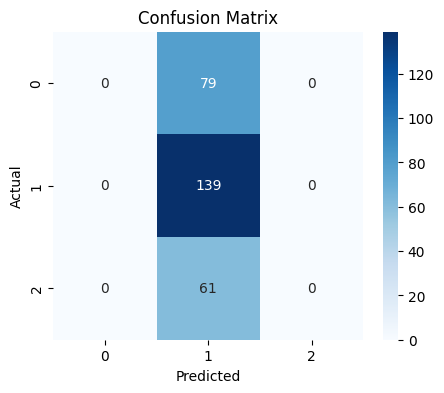

In [116]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


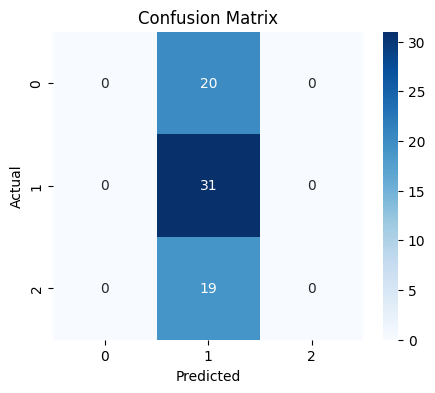

In [120]:
y_test_pred_probs = model.predict(X_test)
y_test_preds = np.argmax(y_test_pred_probs, axis=1)
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [121]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [122]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

In [124]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')  # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,979 (183.51 KB)

 Trainable params: 46,979 (183.51 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.4910 - loss: 1.0860 - val_accuracy: 0.4429 - val_loss: 1.0845
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0677 - val_accuracy: 0.4429 - val_loss: 1.0770
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0472 - val_accuracy: 0.4429 - val_loss: 1.0794
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0406 - val_accuracy: 0.4429 - val_loss: 1.0856
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4982 - loss: 1.0337 - val_accuracy: 0.4429 - val_loss: 1.0913
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0919
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0389 - val_accuracy: 0.4429 - val_loss: 1.0863
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4982 - loss: 1.0386 - val_accuracy: 0.4429 - val_loss: 1.0816


In [126]:
y_train_pred_probs = model.predict(X_train)
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


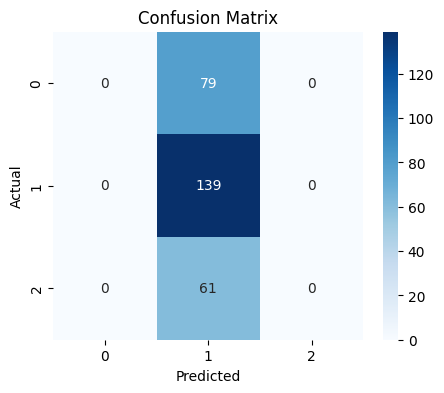

In [127]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

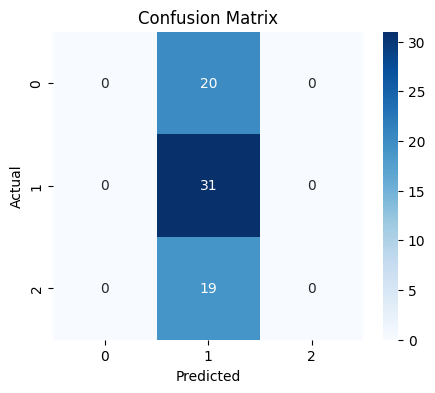

In [128]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

In [129]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


### **Model Performance Summary and Final Model Selection**

In [131]:
# Concatenate the training performance metrics from different models into a single DataFrame
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208
Recall,1.0,0.498208,1.0,0.498208
Precision,1.0,0.248211,1.0,0.248211
F1,1.0,0.331344,1.0,0.331344


In [132]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.457143,0.442857,0.500000,0.442857
Recall,0.457143,0.442857,0.500000,0.442857
Precision,0.318681,0.196122,0.546509,0.196122
F1,0.322500,0.271853,0.442083,0.271853


In [133]:
display(models_train_comp_df)

,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208
Recall,1.0,0.498208,1.0,0.498208
Precision,1.0,0.248211,1.0,0.248211
F1,1.0,0.331344,1.0,0.331344


**Test Performance Comparison:**

In [134]:
display(models_test_comp_df)

,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.457143,0.442857,0.500000,0.442857
Recall,0.457143,0.442857,0.500000,0.442857
Precision,0.318681,0.196122,0.546509,0.196122
F1,0.322500,0.271853,0.442083,0.271853


As you can see from the test performance comparison, the **Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)** model has the highest F1 score of **0.442083**.

### **Sentence Transformer-Random Forest Model Code**

This section outlines the steps to build and evaluate a Random Forest model using embeddings generated by the `BAAI/bge-base-en-v1.5` Sentence Transformer.

Confusion Matrix for Training Data:


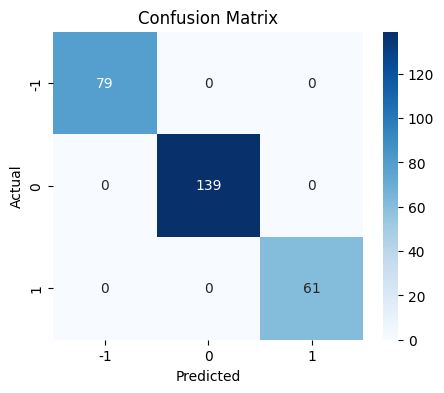

Confusion Matrix for Test Data:


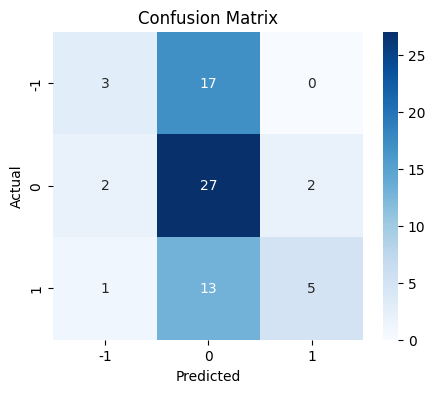


Training set performance metrics:


,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0



Test set performance metrics:


,Accuracy,Recall,Precision,F1
0,0.5,0.5,0.546509,0.442083


In [135]:
# Storing independent variable using Sentence Transformer embeddings
X = embedding_matrix

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the Random Forest model
model_transformer_rf = RandomForestClassifier(random_state=42)

# Fitting on train data
model_transformer_rf.fit(X_train, y_train)

# Make predictions on training and test data
y_pred_train = model_transformer_rf.predict(X_train)
y_pred_test = model_transformer_rf.predict(X_test)

# Plot confusion matrices
print("Confusion Matrix for Training Data:")
plot_confusion_matrix(y_train, y_pred_train)

print("Confusion Matrix for Test Data:")
plot_confusion_matrix(y_test, y_pred_test)

# Get performance metrics
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train, y_pred_train)
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test, y_pred_test)

print("\nTraining set performance metrics:")
display(train_transformer_BAAI_RF)

print("\nTest set performance metrics:")
display(test_transformer_BAAI_RF)

Based on the test performance comparison, the Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest) model performed the best with an F1 score of 0.442083.

### **Making Predictions with the Best Model**

Based on the evaluation metrics, the `Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)` model demonstrated the best performance on the test set. We will use this model to make predictions. Below is an example of making predictions on the first 5 samples of the test set (`X_test`).

In [137]:
# Example: Predict sentiment for a new news article

# Define a new news article for prediction
new_news_article = "Apple's stock soared today after announcing record-breaking iPhone sales for the quarter."

# Reload the SentenceTransformer model into a new variable to avoid conflict with the Sequential model
sentence_transformer_model = SentenceTransformer('BAAI/bge-base-en-v1.5')

# Encode the new news article using the Sentence Transformer model
new_article_embedding = sentence_transformer_model.encode([new_news_article])

# Make a prediction using the best-performing Random Forest model
predicted_sentiment = model_transformer_rf.predict(new_article_embedding)

# Map the numerical prediction to a human-readable sentiment label
sentiment_label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
predicted_sentiment_label = sentiment_label_map[predicted_sentiment[0]]

print(f"News Article: {new_news_article}")
print(f"Predicted Sentiment: {predicted_sentiment_label}")


News Article: Apple's stock soared today after announcing record-breaking iPhone sales for the quarter.
Predicted Sentiment: Neutral


The accuracy of the best-performing model, the Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest) model, is 0.50 (or 50%).



## **Conclusions and Recommendations**

#### **Conclusions**

Based on the comprehensive evaluation of various models and text embeddings for sentiment analysis on news data, here are the key conclusions:

*   **Overfitting is a prominent issue**: Both Random Forest and Neural Network models showed significant overfitting to the training data. Random Forest models achieved perfect metrics (Accuracy, Recall, Precision, F1 = 1.0) on the training set but performed considerably worse on the unseen test data. Neural Networks also exhibited much higher training performance than test performance, indicating a lack of generalization.

*   **Sentence Transformer embeddings outperform Word2Vec**: The `BAAI/bge-base-en-v1.5` Sentence Transformer embeddings generally yielded better performance on the test set compared to Word2Vec embeddings. This suggests that the contextual understanding provided by the Sentence Transformer is more beneficial for capturing the nuances of sentiment in news articles.

*   **Random Forest performed better than Neural Networks in this setup**: Among the models tested, the `Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)` model emerged as the best performer on the test set, achieving an F1-score of **0.442083**. While still moderate, this was the highest F1 score observed. The simple Neural Network architectures used here did not effectively leverage the embeddings, performing worse than Random Forest models.

*   **Challenges in sentiment classification**: The relatively low F1 scores on the test set across all models highlight the inherent difficulty of the sentiment classification task for this specific dataset. Misclassifications, especially confusing negative and neutral sentiments, were evident in the sample predictions.

*   **Need for further optimization**: The current models demonstrate a foundational approach, but there is significant room for improvement in mitigating overfitting and enhancing generalization capabilities.

#### **Recommendations**

To further enhance the sentiment analysis system and address the challenges identified, consider the following recommendations:

*   **Mitigate Overfitting**: The observed severe overfitting in Random Forest models (1.0 F1 on training vs. ~0.44 on test) and the moderate overfitting in Neural Networks necessitate focused efforts to improve generalization.
    *   **For Random Forest**: Experiment with hyperparameter tuning (`max_depth`, `min_samples_split`, `min_samples_leaf`, `n_estimators`) using techniques like GridSearchCV or RandomizedSearchCV. Also, explore ensemble methods or bagging with more diverse base learners.
    *   **For Neural Networks**: Implement regularization techniques such as L1/L2 regularization, early stopping, and more aggressive dropout rates. Consider simpler network architectures if the current ones are too complex for the dataset size.

*   **Enhance Embeddings and Feature Engineering**: While Sentence Transformers showed promise, there's always room for improvement in how text is represented.
    *   **Explore other Sentence Transformer models**: Investigate other state-of-the-art Sentence Transformer models (e.g., from the `sentence-transformers` library) that might be better suited for financial news sentiment. Models trained specifically on financial text could yield better results.
    *   **Combine Embeddings**: Experiment with concatenating different types of embeddings (e.g., Word2Vec and Sentence Transformer embeddings) or incorporating other text features (e.g., TF-IDF, sentiment lexicons).
    *   **Feature Engineering from Price Data**: Integrate features derived from the stock price and volume data (e.g., daily returns, volatility, moving averages, relative strength index) as additional inputs to the sentiment models, as sentiment is often correlated with market movement. This could allow models to learn relationships between news sentiment and market indicators.

*   **Advanced Model Architectures**: Experiment with more sophisticated model architectures.
    *   **Transformers**: Explore fine-tuning pre-trained transformer models (e.g., BERT, RoBERTa, FinBERT) specifically for sentiment analysis on financial news. These models are designed to capture complex contextual relationships in text.
    *   **Recurrent Neural Networks (RNNs) / LSTMs**: If the sequence of words in the news is crucial, consider RNNs or LSTMs, potentially in combination with attention mechanisms, which are good at processing sequential data.

*   **Data Augmentation and More Data**: Given the challenging nature of the task and potentially limited data, consider:
    *   **Collecting more labeled data**: A larger, more diverse dataset of financial news with sentiment labels would significantly help models generalize better.
    *   **Data Augmentation**: Techniques like back-translation, synonym replacement, or contextual word embeddings can expand the training data.

*   **Multi-class Classification Refinement**: The current F1 scores for the three sentiment classes (negative, neutral, positive) indicate difficulty. Analyzing the misclassification patterns (e.g., using more detailed confusion matrices or error analysis) could reveal specific classes that are harder to distinguish and guide targeted improvements.

#End